# VLM Visual Agnosia Experiment

**Research Question:** Do VLMs show human-like patterns of object recognition failure under degraded or fragmented visual input, mirroring the dissociations seen in apperceptive vs. associative visual agnosia?

**Hypothesis:** VLMs will pass degraded line drawings (where bottom-up feature matching is possible) but fail Mooney images (which require top-down global form completion before any recognition is possible). This would suggest their visual processing is texture/feature-based rather than genuinely perceptual, consistent with Marjieh et al.'s finding that visual input does not add perceptual structure beyond what language already captures.

## 1. Setup

In [8]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import base64
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

# Models to test — both accept image inputs
MODELS = [
    "gemini-3-flash-preview",   # available now
    # "claude-sonnet-4-5",      # uncomment after frontier access granted
    # "gemini-2.5-pro",         # uncomment after frontier access granted
]

print("Setup complete.")

Setup complete.


## 2. Load Stimuli

Place your images in the following folders:
- `stimuli/mooney/` — Mooney (two-tone) images, named by object (e.g. `dog_mooney.png`)
- `stimuli/degraded/` — Degraded line drawings of the same objects (e.g. `dog_degraded.png`)

Each Mooney image should have a matching degraded image of the **same object**.

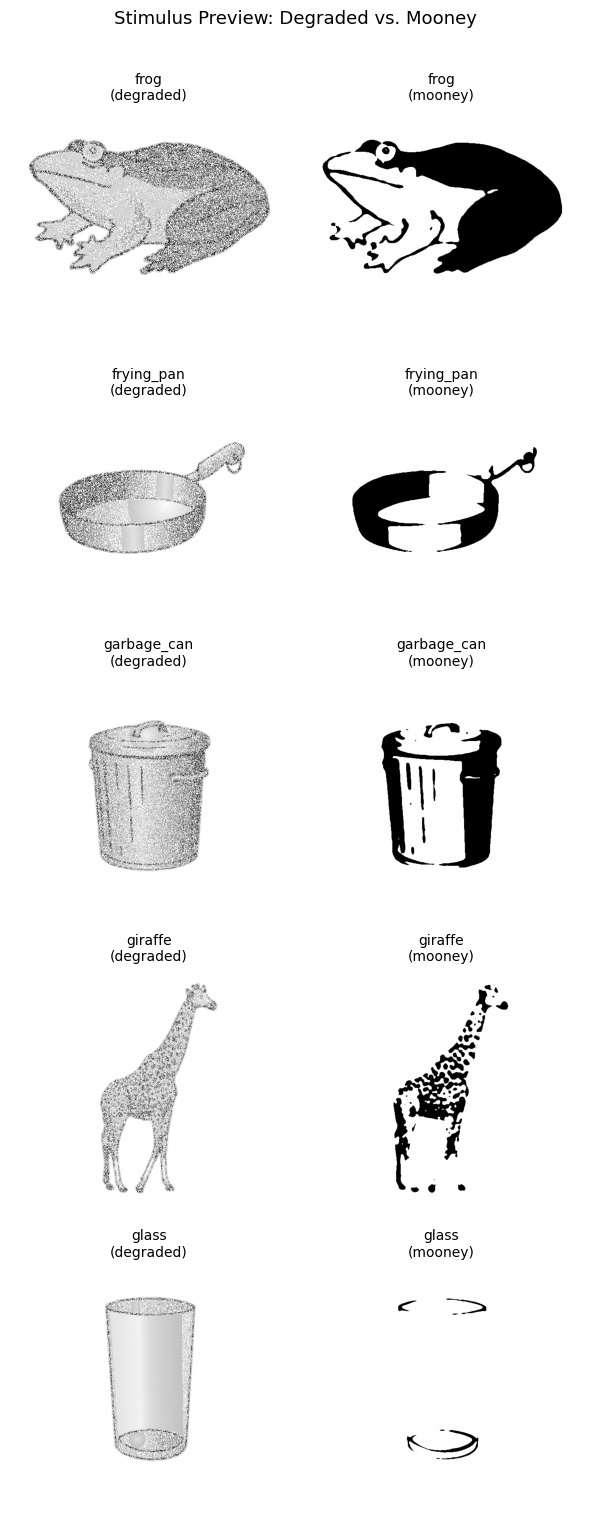

In [9]:
def preview_stimuli(mooney_dir="stimuli/mooney", degraded_dir="stimuli/degraded", n=5):
    """
    Display n matched pairs side by side: degraded (left) vs. Mooney (right).
    """
    mooney_files = sorted([
        f for f in os.listdir(mooney_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    samples = mooney_files[:n]

    fig, axes = plt.subplots(n, 2, figsize=(6, n * 3))
    if n == 1:
        axes = [axes]

    for i, fname in enumerate(samples):
        label = os.path.splitext(fname)[0]

        degraded_path = os.path.join(degraded_dir, fname)
        mooney_path = os.path.join(mooney_dir, fname)

        degraded_img = Image.open(degraded_path).convert("L") if os.path.exists(degraded_path) else None
        mooney_img = Image.open(mooney_path).convert("L") if os.path.exists(mooney_path) else None

        if degraded_img:
            axes[i][0].imshow(degraded_img, cmap="gray")
            axes[i][0].set_title(f"{label}\n(degraded)", fontsize=10)
        axes[i][0].axis("off")

        if mooney_img:
            axes[i][1].imshow(mooney_img, cmap="gray")
            axes[i][1].set_title(f"{label}\n(mooney)", fontsize=10)
        axes[i][1].axis("off")

    plt.suptitle("Stimulus Preview: Degraded vs. Mooney", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


preview_stimuli(n=5)

## 2b. Preview Stimuli

Run this cell after generating stimuli to visually inspect a few matched pairs before running the experiment.

In [10]:
def load_stimuli(mooney_dir="stimuli/mooney", degraded_dir="stimuli/degraded"):
    """
    Load matched pairs of Mooney and degraded images.
    Expects filenames to share the same object label, e.g.:
        mooney/dog.png  <-->  degraded/dog.png
    Returns a list of dicts with keys: label, condition, path
    """
    stimuli = []

    mooney_files = {os.path.splitext(f)[0]: f for f in os.listdir(mooney_dir)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))}
    degraded_files = {os.path.splitext(f)[0]: f for f in os.listdir(degraded_dir)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))}

    matched_labels = set(mooney_files.keys()) & set(degraded_files.keys())
    print(f"Found {len(matched_labels)} matched object pairs.")

    for label in sorted(matched_labels):
        stimuli.append({
            "label": label,
            "condition": "mooney",
            "path": os.path.join(mooney_dir, mooney_files[label])
        })
        stimuli.append({
            "label": label,
            "condition": "degraded",
            "path": os.path.join(degraded_dir, degraded_files[label])
        })

    return stimuli


def encode_image(path):
    """Encode image to base64 string for API."""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


# Preview stimuli list (requires images to be in place)
stimuli = load_stimuli()
pd.DataFrame(stimuli)

Found 161 matched object pairs.


,label,condition,path
0,frog,mooney,stimuli/mooney/frog.png
1,frog,degraded,stimuli/degraded/frog.png
2,frying_pan,mooney,stimuli/mooney/frying_pan.png
3,frying_pan,degraded,stimuli/degraded/frying_pan.png
4,garbage_can,mooney,stimuli/mooney/garbage_can.png
...,...,...,...
317,wineglass,degraded,stimuli/degraded/wineglass.png
318,wrench,mooney,stimuli/mooney/wrench.png
319,wrench,degraded,stimuli/degraded/wrench.png
320,zebra,mooney,stimuli/mooney/zebra.png


## 3. Prompting

We use a simple forced-choice prompt: the model must name the object in the image.
We collect:
- The model's text response
- Whether it matches the true label (correct/incorrect)

To control for prompt sensitivity (autoregressive artifact confound), we use the same prompt across all conditions and models.

In [11]:
SYSTEM_PROMPT = "You are participating in an object recognition experiment. Respond with only the name of the object you see — a single word or short noun phrase. Do not describe the image. Do not say you are unsure. Just name the object."

USER_PROMPT = "What object is in this image?"


def query_model(model, image_path, system_prompt=SYSTEM_PROMPT, user_prompt=USER_PROMPT):
    """
    Send a single image to a VLM and return its text response.
    """
    image_data = encode_image(image_path)
    ext = os.path.splitext(image_path)[-1].lower().replace(".", "")
    mime = "image/jpeg" if ext in ("jpg", "jpeg") else "image/png"

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{image_data}"}},
                    {"type": "text", "text": user_prompt}
                ]
            }
        ],
        reasoning_effort=None
    )

    return response.choices[0].message.content.strip().lower()


def is_correct(response, true_label):
    """
    Check if the model's response matches the true object label.
    Flexible: checks if the true label appears anywhere in the response.
    """
    return true_label.lower() in response.lower()


print("Prompting functions ready.")

Prompting functions ready.


## 4. Run Experiment

In [12]:
def run_experiment(stimuli, models):
    """
    Run all stimuli through all models. Returns a DataFrame of results.
    """
    results = []

    for model in models:
        print(f"\nRunning model: {model}")
        for trial in tqdm(stimuli):
            response = query_model(model, trial["path"])
            correct = is_correct(response, trial["label"])
            results.append({
                "model": model,
                "label": trial["label"],
                "condition": trial["condition"],
                "response": response,
                "correct": correct
            })

    return pd.DataFrame(results)


# Uncomment to run (requires stimuli to be loaded)
stimuli = load_stimuli()
results_df = run_experiment(stimuli, MODELS)
results_df.to_csv("results.csv", index=False)
results_df.head()

Found 161 matched object pairs.

Running model: gemini-3-flash-preview


100%|██████████| 322/322 [10:35<00:00,  1.97s/it]


,model,label,condition,response,correct
0,gemini-3-flash-preview,frog,mooney,frog,True
1,gemini-3-flash-preview,frog,degraded,frog,True
2,gemini-3-flash-preview,frying_pan,mooney,frying pan,False
3,gemini-3-flash-preview,frying_pan,degraded,frying pan,False
4,gemini-3-flash-preview,garbage_can,mooney,trash can,False


## 5. Analysis & Plots

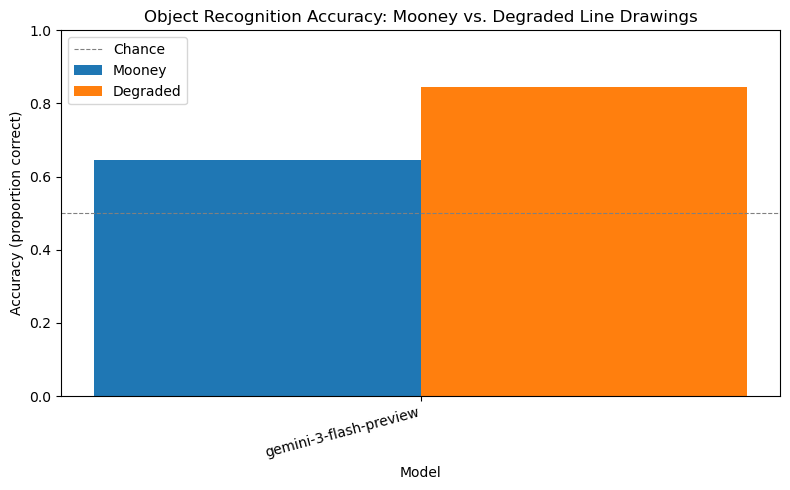

,model,condition,accuracy
0,gemini-3-flash-preview,degraded,0.844720
1,gemini-3-flash-preview,mooney,0.645963


In [13]:
# Load results (if already saved)
results_df = pd.read_csv("results.csv")

def plot_accuracy(results_df):
    """
    Bar chart: accuracy on Mooney vs. degraded conditions, per model.
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]

    models = summary["model"].unique()
    conditions = ["mooney", "degraded"]
    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, condition in enumerate(conditions):
        vals = [summary[(summary["model"] == m) & (summary["condition"] == condition)]["accuracy"].values[0]
                for m in models]
        ax.bar(x + i * width, vals, width, label=condition.capitalize())

    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("Object Recognition Accuracy: Mooney vs. Degraded Line Drawings")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
    ax.legend()
    plt.tight_layout()
    plt.savefig("accuracy_by_condition.png", dpi=150)
    plt.show()

    return summary


plot_accuracy(results_df)

## 6. Human Comparison

Human benchmark data from the literature:

- **Mooney images (objects):** ~34% spontaneous recognition before any disambiguation cue (Snodgrass & Corwin, 1988). Recognition of non-face Mooney objects is substantially lower than faces and highly variable.
- **Degraded line drawings (S&V fragmentation):** ~35% correct at threshold fragmentation level (Snodgrass & Corwin, 1988); up to ~63% for easier items (Koch et al., 1995).

**Caveat:** No published study provides human norms for exactly our degradation method (50% random line pixel removal). These numbers are the closest available approximation.

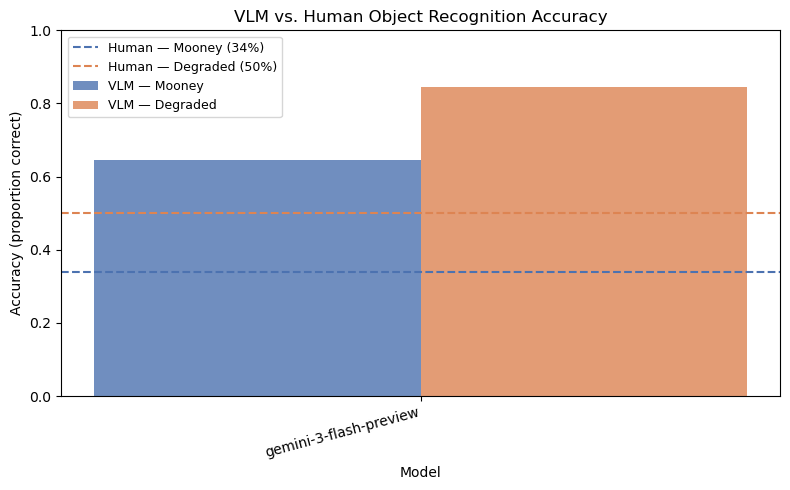

In [14]:
def plot_with_human_baseline(results_df, human_mooney=0.34, human_degraded=0.50):
    """
    Same bar chart as above but with human baseline overlaid as horizontal lines.
    """
    summary = results_df.groupby(["model", "condition"])["correct"].mean().reset_index()
    summary.columns = ["model", "condition", "accuracy"]

    models = summary["model"].unique()
    conditions = ["mooney", "degraded"]
    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    colors = ["#4C72B0", "#DD8452"]
    for i, condition in enumerate(conditions):
        vals = [summary[(summary["model"] == m) & (summary["condition"] == condition)]["accuracy"].values[0]
                for m in models]
        ax.bar(x + i * width, vals, width, label=f"VLM — {condition.capitalize()}", color=colors[i], alpha=0.8)

    ax.axhline(human_mooney, color=colors[0], linestyle="--", linewidth=1.5, label=f"Human — Mooney ({human_mooney:.0%})")
    ax.axhline(human_degraded, color=colors[1], linestyle="--", linewidth=1.5, label=f"Human — Degraded ({human_degraded:.0%})")

    ax.set_xlabel("Model")
    ax.set_ylabel("Accuracy (proportion correct)")
    ax.set_title("VLM vs. Human Object Recognition Accuracy")
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([m.split("/")[-1] for m in models], rotation=15, ha="right")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("accuracy_with_human_baseline.png", dpi=150)
    plt.show()


plot_with_human_baseline(results_df)